# Alzheimer's Disease Detection — MRI Classification
**Classes:** Non Demented | Very Mild Demented | Mild Demented | Moderate Demented

---

## Step 1 — Problem Analysis
### What is Alzheimer's Disease?
Alzheimer's is a brain disease that slowly destroys memory and thinking skills. Doctors use **MRI brain scans** to detect how severe the damage is.

### Goal
Classify an MRI image into one of 4 stages:
- **Non Demented** — healthy brain
- **Very Mild Demented** — very early signs
- **Mild Demented** — clear signs of damage
- **Moderate Demented** — significant brain damage

This is a **multi-class image classification** problem solved with Transfer Learning (CNNs).

## Step 2 — Data Collection
Downloading the MRI dataset from Kaggle.

In [ ]:
# Install all required libraries
!pip install -q tensorflow keras numpy pandas matplotlib seaborn scikit-learn opencv-python kagglehub

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

print('Libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

Libraries imported successfully!
TensorFlow version: 2.19.0


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Download the OASIS Alzheimer MRI dataset from Kaggle
import kagglehub
# NOTE: First time — upload your kaggle.json API key:
# from google.colab import files; files.upload()
# !mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

path = kagglehub.dataset_download('ninadaithal/imagesoasis')
DATA_DIR = os.path.join(path, 'Data') if os.path.exists(os.path.join(path, 'Data')) else path
print(f'Dataset downloaded at: {DATA_DIR}')
print(f'Folders inside: {os.listdir(DATA_DIR)}')

Mounted at /content/drive
Using Colab cache for faster access to the 'imagesoasis' dataset.
Dataset downloaded at: /kaggle/input/imagesoasis/Data
Folders inside: ['Non Demented', 'Very mild Dementia', 'Moderate Dementia', 'Mild Dementia']


## Step 3 — Explore the Data
Count images per class and visualise samples.

Image count per class:
-----------------------------------
  Mild Dementia             : 5002 images
  Moderate Dementia         : 488 images
  Non Demented              : 67222 images
  Very mild Dementia        : 13725 images
-----------------------------------
  Total images          : 86437


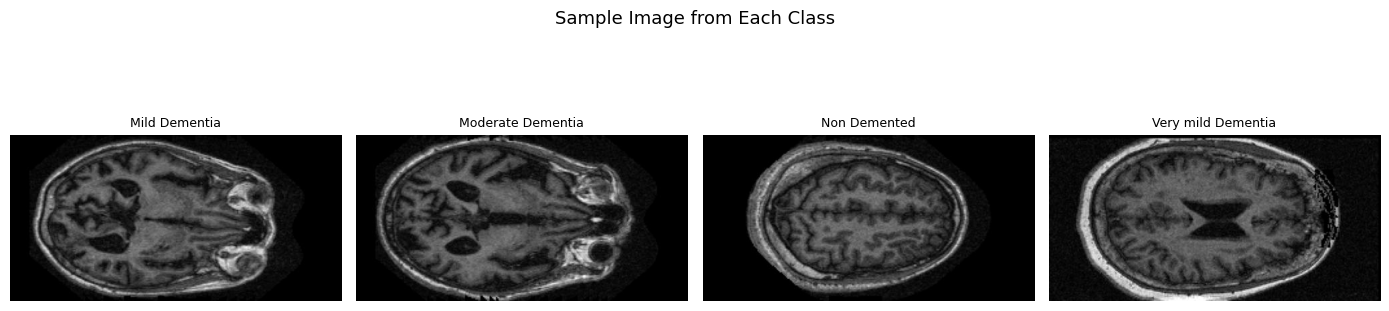

In [ ]:
print('Image count per class:')
print('-' * 35)
all_images = []
all_labels = []
total = 0
for folder in sorted(os.listdir(DATA_DIR)):
    folder_path = os.path.join(DATA_DIR, folder)
    if os.path.isdir(folder_path):
        files = [f for f in os.listdir(folder_path)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        count = len(files)
        print(f'  {folder:<25} : {count} images')
        total += count
        for filename in files:
            all_images.append(os.path.join(folder_path, filename))
            all_labels.append(folder)
print('-' * 35)
print(f'  Total images          : {total}')

CLASS_NAMES = sorted(set(all_labels))
NUM_CLASSES = len(CLASS_NAMES)

plt.figure(figsize=(14, 4))
for i, class_name in enumerate(CLASS_NAMES):
    idx = all_labels.index(class_name)
    img = cv2.imread(all_images[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, NUM_CLASSES, i+1)
    plt.imshow(img)
    plt.title(class_name, fontsize=9)
    plt.axis('off')
plt.suptitle('Sample Image from Each Class', fontsize=13)
plt.tight_layout()
plt.show()

## Step 4 — Splitting the Data
- **Train (70%)** — model learns from this
- **Validation (15%)** — checked during training
- **Test (15%)** — final evaluation only (model has never seen this)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.30, stratify=all_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)
print(f'Training images   : {len(X_train)}')
print(f'Validation images : {len(X_val)}')
print(f'Test images       : {len(X_test)}')

Training images   : 60505
Validation images : 12966
Test images       : 12966


In [ ]:
SPLIT_DIR = '/content/split_data'
for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

def copy_images(paths, labels, split_name):
    for img_path, label in zip(paths, labels):
        shutil.copy(img_path, os.path.join(SPLIT_DIR, split_name, label))

copy_images(X_train, y_train, 'train')
copy_images(X_val,   y_val,   'val')
copy_images(X_test,  y_test,  'test')
print('Images copied into train / val / test folders successfully!')

Images copied into train / val / test folders successfully!


## Step 5 — Data Balancing
Calculate **class weights** so the model pays more attention to under-represented classes.

Training set — images per class:
-----------------------------------
  Mild Dementia             : 3501
  Moderate Dementia         : 342
  Non Demented              : 47055
  Very mild Dementia        : 9607


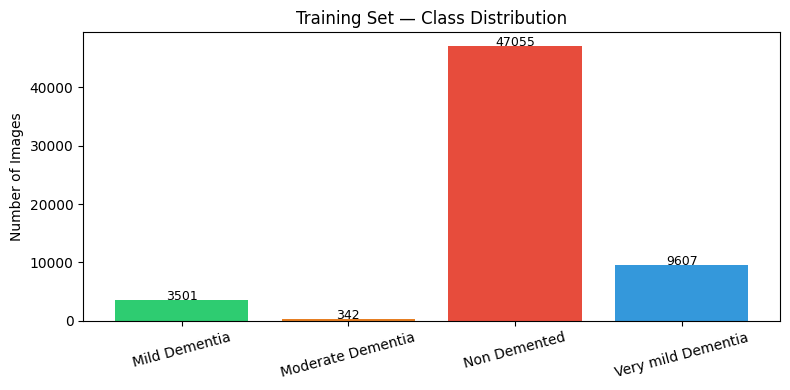

In [ ]:
print('Training set — images per class:')
print('-' * 35)
for cls in CLASS_NAMES:
    print(f'  {cls:<25} : {y_train.count(cls)}')

counts = [y_train.count(cls) for cls in CLASS_NAMES]
plt.figure(figsize=(8, 4))
bars = plt.bar(CLASS_NAMES, counts, color=['#2ecc71','#e67e22','#e74c3c','#3498db'])
plt.title('Training Set — Class Distribution')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)
for bar, v in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
label_to_idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}
y_train_nums = [label_to_idx[l] for l in y_train]
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(range(NUM_CLASSES)),
    y=y_train_nums
)
class_weights = dict(enumerate(weights))
print('Class Weights (higher = more attention):')
for cls, w in zip(CLASS_NAMES, weights):
    print(f'  {cls:<25} : {w:.4f}')

Class Weights (higher = more attention):
  Mild Dementia             : 4.3206
  Moderate Dementia         : 44.2288
  Non Demented              : 0.3215
  Very mild Dementia        : 1.5745


## Step 6 — Training Setup
Data generators, callbacks, and evaluation helper.

In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

# MRI-specific augmentation — no horizontal flip (brain scans shouldn't be mirrored)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=False,
    shear_range=0.1
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'train'), target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical'
)
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'val'), target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_DIR, 'test'), target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}')

Found 60505 images belonging to 4 classes.
Found 12966 images belonging to 4 classes.
Found 12966 images belonging to 4 classes.
Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']


In [ ]:
def evaluate_model(model, history, model_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'],     label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} — Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'],     label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{model_name} — Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout(); plt.show()

    test_generator.reset()
    y_pred_probs = model.predict(test_generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_generator.classes

    print(f'\n--- {model_name} — Classification Report ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.xticks(rotation=15); plt.tight_layout(); plt.show()

    test_loss, test_acc = model.evaluate(test_generator, verbose=0)
    print(f'{model_name} — Test Accuracy: {test_acc:.4f}')
    return test_acc

print('Helper function ready!')

Helper function ready!


## Step 7 — Train MobileNetV2
MobileNetV2 is designed to be lightweight — ideal for deployment on phones and edge devices.
We use **transfer learning**: start from ImageNet weights, freeze early layers, fine-tune the last 30.

In [ ]:
from tensorflow.keras.applications import MobileNetV2

# ── BUILD ──
base_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_mobile.trainable = True
for layer in base_mobile.layers[:-30]:  # freeze early layers
    layer.trainable = False

mobile_model = Sequential([
    base_mobile,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# ── COMPILE ──
mobile_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
mobile_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 1,855,364 (7.08 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [11]:
# ── TRAIN ──
history_mobile = mobile_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 874s 447ms/step - accuracy: 0.7091 - loss: 0.6249 - val_accuracy: 0.8387 - val_loss: 0.3756 - learning_rate: 1.0000e-04
Epoch 2/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 841s 445ms/step - accuracy: 0.8549 - loss: 0.2453 - val_accuracy: 0.8222 - val_loss: 0.5224 - learning_rate: 1.0000e-04
Epoch 3/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 822s 434ms/step - accuracy: 0.9073 - loss: 0.1426 - val_accuracy: 0.9291 - val_loss: 0.1958 - learning_rate: 1.0000e-04
Epoch 4/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 838s 443ms/step - accuracy: 0.9276 - loss: 0.1196 - val_accuracy: 0.9667 - val_loss: 0.0895 - learning_rate: 1.0000e-04
Epoch 5/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 856s 452ms/step - accuracy: 0.9393 - loss: 0.1102 - val_accuracy: 0.9683 - val_loss: 0.0884 - learning_rate: 1.0000e-04
Epoch 6/20
1891/1891 ━━━━━━━━━━━━━━━━━━━━ 872s 461ms/step - accuracy: 0.9474 - loss: 0.0928 - val_accuracy: 0.9007 - val_loss: 0.3264 - learning_rate: 1.0000e-04
Epoch 7/20
1891/1891 ━━━━━━━

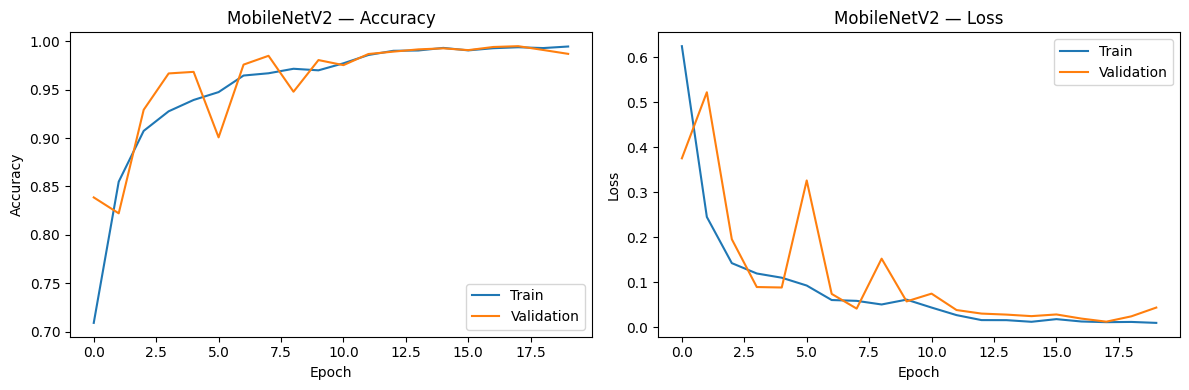

406/406 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step

--- MobileNetV2 — Classification Report ---
                    precision    recall  f1-score   support

     Mild Dementia       0.98      1.00      0.99       751
 Moderate Dementia       1.00      1.00      1.00        73
      Non Demented       1.00      1.00      1.00     10083
Very mild Dementia       0.99      0.98      0.99      2059

          accuracy                           0.99     12966
         macro avg       0.99      0.99      0.99     12966
      weighted avg       0.99      0.99      0.99     12966



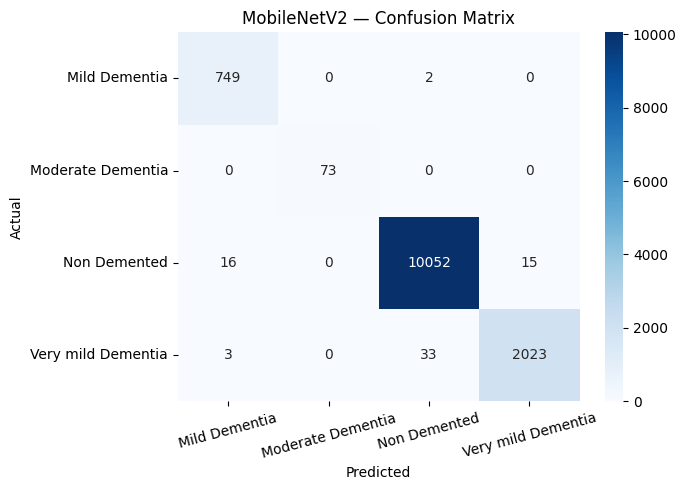

MobileNetV2 — Test Accuracy: 0.9947


In [17]:
# ── EVALUATE ──
test_acc = evaluate_model(mobile_model, history_mobile, 'MobileNetV2')

In [20]:
# ── SAVE ──
# 1. Save locally inside Colab (temporary — lost when session ends)
LOCAL_PATH = '/content/model_mobilenet.h5'
mobile_model.save(LOCAL_PATH)
print(f'Saved locally to: {LOCAL_PATH}')

# 2. Save to Google Drive (permanent — survives session restarts)
DRIVE_PATH = '/content/drive/MyDrive/model_mobilenet.h5'
mobile_model.save(DRIVE_PATH)
print(f'Saved to Google Drive: {DRIVE_PATH}')

print(f'\nTest Accuracy: {test_acc:.4f}')
print('Both saves complete!')

Saved locally to: /content/model_mobilenet.h5
Saved to Google Drive: /content/drive/MyDrive/model_mobilenet.h5

Test Accuracy: 0.9947
Both saves complete!


In [21]:
# ── SAVE ──
# 1. Save locally inside Colab (temporary — lost when session ends)
LOCAL_PATH = '/content/model_mobilenet.h5'
mobile_model.save(LOCAL_PATH)
print(f'Saved locally to: {LOCAL_PATH}')

# 2. Save to Google Drive (permanent — survives session restarts)
DRIVE_PATH = '/content/drive/MyDrive/model_mobilenet.h5'
mobile_model.save(DRIVE_PATH)
print(f'Saved to Google Drive: {DRIVE_PATH}')

print(f'\nTest Accuracy: {test_acc:.4f}')
print('Both saves complete!')

Saved locally to: /content/model_mobilenet.h5
Saved to Google Drive: /content/drive/MyDrive/model_mobilenet.h5

Test Accuracy: 0.9947
Both saves complete!
